In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("5-star edible sushi.csv")

print("Shape:", df.shape)
print("\nTarget distribution:")
print(df["target_cost_overrun_12m"].value_counts(dropna=False))

Shape: (109787, 52)

Target distribution:
target_cost_overrun_12m
0.0    77759
NaN    25317
1.0     6711
Name: count, dtype: int64


In [7]:
df.head()

,project_id,report_month,month,year,sector,state,approval_year,project_age,original_duration_months,duration_overrun_months,...,expenditure_progress_gap_anti,cost_rebaseline_signal,schedule_progress_mismatch,early_phase_milestone_artifact,agency_overrun_rate,agency_project_count_as_of_T,sector_overrun_rate,target_cost_overrun_12m,target_schedule_risk_12m,cost_target_valid
0,120100067,2015-04-01,4,2015,STEEL,ANDHRA PRADESH,2005,114.0,48.0,66.0,...,-6.624231,0.0,138.928571,False,0.238095,0.0,0.238095,NaN,NaN,0
1,120100067,2015-05-01,5,2015,STEEL,ANDHRA PRADESH,2005,115.0,48.0,67.0,...,-6.425631,0.0,141.011905,False,0.238095,0.0,0.238095,NaN,NaN,0
2,120100067,2015-06-01,6,2015,STEEL,ANDHRA PRADESH,2005,116.0,48.0,68.0,...,-6.314330,0.0,143.095238,False,0.238095,0.0,0.238095,NaN,NaN,0
3,120100067,2015-07-01,7,2015,STEEL,ANDHRA PRADESH,2005,117.0,48.0,69.0,...,-6.063252,0.0,145.178571,False,0.238095,0.0,0.238095,NaN,NaN,0
4,120100067,2015-08-01,8,2015,STEEL,ANDHRA PRADESH,2005,118.0,48.0,70.0,...,-7.055895,0.0,145.833333,False,0.238095,0.0,0.238095,NaN,NaN,0


In [2]:
target = "target_cost_overrun_12m"

drop_cols = [
    "project_id",
    "project_name",
    "report_month",
    "target_cost_overrun_12m",
    "target_schedule_risk_12m",
    "cost_target_valid",

    # identifiers / source information
    "serial_no",
    "source_file",
    "source_page",

    # high-cardinality raw categorical field
    "implementing_agency"
]

drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (109787, 47)
y shape: (109787,)


In [3]:
mask = y.notna()

X = X.loc[mask].copy()
y = y.loc[mask].astype(int)

print("Training rows:", len(X))
print("\nTarget distribution:")
print(y.value_counts())
print("\nPositive rate:", y.mean())

Training rows: 84470

Target distribution:
target_cost_overrun_12m
0    77759
1     6711
Name: count, dtype: int64

Positive rate: 0.07944832484905884


In [5]:
df["report_month"] = pd.to_datetime(df["report_month"])

In [8]:
# Make sure report_month is datetime
df["report_month"] = pd.to_datetime(df["report_month"])

# Keep only rows where the target exists
mask = df["target_cost_overrun_12m"].notna()

# Time-based split
split_date = pd.Timestamp("2021-01-01")

train_mask = mask & (df["report_month"] < split_date)
test_mask  = mask & (df["report_month"] >= split_date)

# Create X and y
drop_cols = [
    "project_id",
    "project_name",
    "report_month",
    "target_cost_overrun_12m",
    "target_schedule_risk_12m",
    "cost_target_valid",
    "serial_no",
    "source_file",
    "source_page",
    "implementing_agency"
]

drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df["target_cost_overrun_12m"]

# Split
X_train = X.loc[train_mask].copy()
X_test  = X.loc[test_mask].copy()

y_train = y.loc[train_mask].astype(int)
y_test  = y.loc[test_mask].astype(int)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

print("\nTrain positive rate:", round(y_train.mean(), 4))
print("Test positive rate :", round(y_test.mean(), 4))

Train: (77077, 47)
Test : (7393, 47)

Train target distribution:
target_cost_overrun_12m
0    70992
1     6085
Name: count, dtype: int64

Test target distribution:
target_cost_overrun_12m
0    6767
1     626
Name: count, dtype: int64

Train positive rate: 0.0789
Test positive rate : 0.0847


"Step 2.1A — Preprocessing"

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import numpy as np

# Identify column types
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Number of numeric columns:", len(numeric_cols))

Categorical columns: ['sector', 'state']
Number of numeric columns: 43


C:\Users\vatsh\AppData\Local\Temp\ipykernel_9628\2305909101.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import numpy as np

# Identify feature types
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# Logistic Regression
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

print("Training Logistic Regression...")

logistic_model.fit(X_train, y_train)

print("✅ Logistic Regression trained successfully!")

C:\Users\vatsh\AppData\Local\Temp\ipykernel_9628\2677053236.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(


Training Logistic Regression...
✅ Logistic Regression trained successfully!


In [13]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Predictions
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# Metrics
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("===== COST OVERRUN — LOGISTIC REGRESSION =====")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

===== COST OVERRUN — LOGISTIC REGRESSION =====
Precision : 0.1269
Recall    : 0.5463
F1 Score  : 0.2060
ROC-AUC   : 0.6073
PR-AUC    : 0.1257

Confusion Matrix:
[[4414 2353]
 [ 284  342]]


In [15]:
from xgboost import XGBClassifier

# Calculate class imbalance weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Scale positive weight:", round(scale_pos_weight, 2))

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

print("Training XGBoost...")

xgb_model.fit(X_train, y_train)

print("✅ XGBoost trained successfully!")

Scale positive weight: 11.67
Training XGBoost...
✅ XGBoost trained successfully!


In [16]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("===== COST OVERRUN — XGBOOST =====")
print(f"Precision : {precision_score(y_test, y_pred_xgb, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_xgb, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_xgb, zero_division=0):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"PR-AUC    : {average_precision_score(y_test, y_prob_xgb):.4f}")

===== COST OVERRUN — XGBOOST =====
Precision : 0.3385
Recall    : 0.4153
F1 Score  : 0.3730
ROC-AUC   : 0.7541
PR-AUC    : 0.2873


Phase 2.3 — XGBoost Hyperparameter Tuning

In [17]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, average_precision_score
import numpy as np

# ---------------------------------------------------------
# 1. Create temporal folds from the TRAINING data
# ---------------------------------------------------------

train_dates = df.loc[X_train.index, "report_month"]

# Sort training indices chronologically
sorted_idx = train_dates.sort_values().index

n = len(sorted_idx)

# Three walk-forward folds
fold1_train_end = int(n * 0.50)
fold1_val_end   = int(n * 0.65)

fold2_train_end = int(n * 0.65)
fold2_val_end   = int(n * 0.80)

fold3_train_end = int(n * 0.80)
fold3_val_end   = n

folds = [
    (
        sorted_idx[:fold1_train_end],
        sorted_idx[fold1_train_end:fold1_val_end]
    ),
    (
        sorted_idx[:fold2_train_end],
        sorted_idx[fold2_train_end:fold2_val_end]
    ),
    (
        sorted_idx[:fold3_train_end],
        sorted_idx[fold3_train_end:fold3_val_end]
    )
]

# Convert original dataframe indices -> positions inside X_train
index_to_position = {
    idx: pos for pos, idx in enumerate(X_train.index)
}

cv_splits = []

for train_indices, val_indices in folds:
    train_positions = [
        index_to_position[i]
        for i in train_indices
        if i in index_to_position
    ]

    val_positions = [
        index_to_position[i]
        for i in val_indices
        if i in index_to_position
    ]

    cv_splits.append((train_positions, val_positions))

print("Walk-forward folds created:")
for i, (tr, va) in enumerate(cv_splits, 1):
    print(f"Fold {i}: Train={len(tr):,}, Validation={len(va):,}")

Walk-forward folds created:
Fold 1: Train=38,538, Validation=11,562
Fold 2: Train=50,100, Validation=11,561
Fold 3: Train=61,661, Validation=15,416


In [18]:
# ---------------------------------------------------------
# 2. XGBoost hyperparameter search
# ---------------------------------------------------------

from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_base)
])

param_grid = {
    "model__n_estimators": [300, 500, 700, 900],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.02, 0.05, 0.08, 0.1],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__gamma": [0, 0.1, 0.3, 0.5]
}

search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=12,
    scoring="average_precision",
    cv=cv_splits,
    random_state=42,
    n_jobs=1,
    verbose=1,
    refit=True
)

print("Starting walk-forward XGBoost tuning...")

search.fit(X_train, y_train)

print("\n✅ Tuning complete!")
print("\nBest walk-forward PR-AUC:")
print(round(search.best_score_, 4))

print("\nBest parameters:")
for key, value in search.best_params_.items():
    print(f"{key}: {value}")

Starting walk-forward XGBoost tuning...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

✅ Tuning complete!

Best walk-forward PR-AUC:
0.4321

Best parameters:
model__subsample: 0.9
model__n_estimators: 700
model__min_child_weight: 1
model__max_depth: 8
model__learning_rate: 0.05
model__gamma: 0.5
model__colsample_bytree: 0.6


In [19]:
# ---------------------------------------------------------
# 3. Evaluate tuned model on the held-out test set
# ---------------------------------------------------------

best_xgb = search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("===== TUNED XGBOOST — COST OVERRUN =====")

print(f"Precision : {precision_score(y_test, y_pred_tuned, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_tuned, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_tuned, zero_division=0):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"PR-AUC    : {average_precision_score(y_test, y_prob_tuned):.4f}")

===== TUNED XGBOOST — COST OVERRUN =====
Precision : 0.5865
Recall    : 0.3738
F1 Score  : 0.4566
ROC-AUC   : 0.7932
PR-AUC    : 0.4368


In [20]:
cost_model_results = {
    "Model": [
        "Logistic Regression",
        "XGBoost Baseline",
        "Tuned XGBoost"
    ],
    "PR-AUC": [
        0.1257,
        0.2873,
        0.4368
    ],
    "ROC-AUC": [
        0.6073,
        0.7541,
        0.7932
    ],
    "F1": [
        0.2060,
        0.3730,
        0.4566
    ]
}

cost_model_results_df = pd.DataFrame(cost_model_results)

cost_model_results_df

,Model,PR-AUC,ROC-AUC,F1
0,Logistic Regression,0.1257,0.6073,0.2060
1,XGBoost Baseline,0.2873,0.7541,0.3730
2,Tuned XGBoost,0.4368,0.7932,0.4566


Model B — Schedule Risk Classifier

In [21]:
# ============================================================
# PHASE 2.2 — SCHEDULE RISK MODEL
# ============================================================

# Target
schedule_target = "target_schedule_risk_12m"

# Keep only rows where schedule outcome is known
schedule_mask = df[schedule_target].notna()

# Same chronological split as cost model
split_date = pd.Timestamp("2021-01-01")

train_mask_schedule = (
    schedule_mask &
    (df["report_month"] < split_date)
)

test_mask_schedule = (
    schedule_mask &
    (df["report_month"] >= split_date)
)

# X is already cleaned of target/leakage columns
X_schedule_train = X.loc[train_mask_schedule].copy()
X_schedule_test = X.loc[test_mask_schedule].copy()

y_schedule_train = (
    df.loc[train_mask_schedule, schedule_target]
    .astype(int)
)

y_schedule_test = (
    df.loc[test_mask_schedule, schedule_target]
    .astype(int)
)

print("===== SCHEDULE TARGET =====")
print("Train:", X_schedule_train.shape)
print("Test :", X_schedule_test.shape)

print("\nTrain distribution:")
print(y_schedule_train.value_counts())

print("\nTest distribution:")
print(y_schedule_test.value_counts())

print("\nTrain positive rate:",
      round(y_schedule_train.mean(), 4))

print("Test positive rate:",
      round(y_schedule_test.mean(), 4))

===== SCHEDULE TARGET =====
Train: (52041, 47)
Test : (4825, 47)

Train distribution:
target_schedule_risk_12m
0    38041
1    14000
Name: count, dtype: int64

Test distribution:
target_schedule_risk_12m
0    3208
1    1617
Name: count, dtype: int64

Train positive rate: 0.269
Test positive rate: 0.3351


In [22]:
from xgboost import XGBClassifier

schedule_scale_pos_weight = (
    (y_schedule_train == 0).sum()
    / (y_schedule_train == 1).sum()
)

schedule_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0,
        scale_pos_weight=schedule_scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

print("Training Schedule XGBoost...")

schedule_xgb.fit(
    X_schedule_train,
    y_schedule_train
)

print("✅ Schedule XGBoost trained!")

Training Schedule XGBoost...
✅ Schedule XGBoost trained!


In [23]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

y_pred_schedule = schedule_xgb.predict(X_schedule_test)
y_prob_schedule = schedule_xgb.predict_proba(
    X_schedule_test
)[:, 1]

print("===== SCHEDULE RISK — XGBOOST =====")

print(f"Precision : {precision_score(y_schedule_test, y_pred_schedule, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_schedule_test, y_pred_schedule, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_schedule_test, y_pred_schedule, zero_division=0):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_schedule_test, y_prob_schedule):.4f}")
print(f"PR-AUC    : {average_precision_score(y_schedule_test, y_prob_schedule):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_schedule_test, y_pred_schedule))

===== SCHEDULE RISK — XGBOOST =====
Precision : 0.6468
Recall    : 0.7699
F1 Score  : 0.7030
ROC-AUC   : 0.8710
PR-AUC    : 0.7511

Confusion Matrix:
[[2528  680]
 [ 372 1245]]


In [24]:
# ============================================================
# SCHEDULE XGBOOST — WALK-FORWARD HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

# Sort schedule training data chronologically
schedule_dates = df.loc[
    X_schedule_train.index, "report_month"
]

sorted_schedule_idx = schedule_dates.sort_values().index

n = len(sorted_schedule_idx)

# 3 walk-forward folds
folds_schedule = [
    (
        sorted_schedule_idx[:int(n * 0.50)],
        sorted_schedule_idx[int(n * 0.50):int(n * 0.65)]
    ),
    (
        sorted_schedule_idx[:int(n * 0.65)],
        sorted_schedule_idx[int(n * 0.65):int(n * 0.80)]
    ),
    (
        sorted_schedule_idx[:int(n * 0.80)],
        sorted_schedule_idx[int(n * 0.80):]
    )
]

index_to_position_schedule = {
    idx: pos for pos, idx in enumerate(X_schedule_train.index)
}

cv_schedule = []

for train_indices, val_indices in folds_schedule:

    train_positions = [
        index_to_position_schedule[i]
        for i in train_indices
        if i in index_to_position_schedule
    ]

    val_positions = [
        index_to_position_schedule[i]
        for i in val_indices
        if i in index_to_position_schedule
    ]

    # Only keep folds with both classes
    if (
        len(train_positions) > 0
        and len(val_positions) > 0
        and y_schedule_train.iloc[train_positions].nunique() == 2
        and y_schedule_train.iloc[val_positions].nunique() == 2
    ):
        cv_schedule.append(
            (train_positions, val_positions)
        )

print("Walk-forward folds:", len(cv_schedule))

Walk-forward folds: 3


In [25]:
# ============================================================
# RANDOMIZED SEARCH
# ============================================================

schedule_xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=schedule_scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

schedule_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", schedule_xgb_base)
])

schedule_params = {
    "model__n_estimators": [300, 500, 700, 900],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.02, 0.05, 0.08, 0.1],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__gamma": [0, 0.1, 0.3, 0.5]
}

schedule_search = RandomizedSearchCV(
    estimator=schedule_pipeline,
    param_distributions=schedule_params,
    n_iter=12,
    scoring="average_precision",
    cv=cv_schedule,
    random_state=42,
    n_jobs=1,
    verbose=1,
    refit=True
)

print("Tuning Schedule XGBoost...")

schedule_search.fit(
    X_schedule_train,
    y_schedule_train
)

print("\n✅ Schedule tuning complete!")
print("Best walk-forward PR-AUC:",
      round(schedule_search.best_score_, 4))

print("\nBest parameters:")
for key, value in schedule_search.best_params_.items():
    print(key, "=", value)

Tuning Schedule XGBoost...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

✅ Schedule tuning complete!
Best walk-forward PR-AUC: 0.6963

Best parameters:
model__subsample = 0.9
model__n_estimators = 700
model__min_child_weight = 1
model__max_depth = 8
model__learning_rate = 0.05
model__gamma = 0.5
model__colsample_bytree = 0.6


In [26]:
# Evaluate tuned schedule model on the held-out test set

best_schedule_model = schedule_search.best_estimator_

y_schedule_prob_tuned = best_schedule_model.predict_proba(X_schedule_test)[:, 1]
y_schedule_pred_tuned = (y_schedule_prob_tuned >= 0.5).astype(int)

print("Tuned Schedule Model - Test Results")
print("Precision:", precision_score(y_schedule_test, y_schedule_pred_tuned))
print("Recall:", recall_score(y_schedule_test, y_schedule_pred_tuned))
print("F1:", f1_score(y_schedule_test, y_schedule_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_schedule_test, y_schedule_prob_tuned))
print("PR-AUC:", average_precision_score(y_schedule_test, y_schedule_prob_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_schedule_test, y_schedule_pred_tuned))

Tuned Schedule Model - Test Results
Precision: 0.7386511024643321
Recall: 0.7043908472479901
F1: 0.7211142766698322
ROC-AUC: 0.8953963074688048
PR-AUC: 0.8090767928009029

Confusion Matrix:
[[2805  403]
 [ 478 1139]]


In [31]:
from sklearn.metrics import brier_score_loss

xgb_brier = brier_score_loss(y_test, y_prob_xgb)

print("Dummy Brier Score:", dummy_brier)
print("Untuned XGBoost Brier Score:", xgb_brier)
print("Brier Improvement:", dummy_brier - xgb_brier)

Dummy Brier Score: 0.07753769491389263
Untuned XGBoost Brier Score: 0.09261956810951233
Brier Improvement: -0.015081873195619697


In [33]:
from sklearn.metrics import brier_score_loss

schedule_dummy_prob = y_schedule_train.mean()

schedule_dummy_brier = brier_score_loss(
    y_schedule_test,
    [schedule_dummy_prob] * len(y_schedule_test)
)

schedule_xgb_brier = brier_score_loss(
    y_schedule_test,
    y_prob_schedule
)

print("Schedule Dummy Brier:", schedule_dummy_brier)
print("Schedule Untuned XGBoost Brier:", schedule_xgb_brier)
print("Brier Improvement:", schedule_dummy_brier - schedule_xgb_brier)

Schedule Dummy Brier: 0.22718837716969809
Schedule Untuned XGBoost Brier: 0.14109225571155548
Brier Improvement: 0.0860961214581426


In [34]:
# ==========================================
# PHASE 1 — FINAL BASELINE RESULTS
# ==========================================

phase1_results = pd.DataFrame({
    "Target": [
        "Cost Overrun",
        "Cost Overrun",
        "Cost Overrun",
        "Schedule / Time Risk",
        "Schedule / Time Risk"
    ],
    "Model": [
        "Dummy / Majority",
        "Logistic Regression",
        "Untuned XGBoost",
        "Dummy / Majority",
        "Untuned XGBoost"
    ],
    "PR-AUC": [
        None,
        0.1257,
        0.2873,
        None,
        0.7511
    ],
    "Brier Score": [
        0.0775,
        None,
        0.0926,
        0.2272,
        0.1411
    ],
    "F1": [
        None,
        0.2060,
        0.3730,
        None,
        0.7030
    ]
})

print("PHASE 1 — FINAL BASELINE RESULTS")
display(phase1_results.round(4))

PHASE 1 — FINAL BASELINE RESULTS


,Target,Model,PR-AUC,Brier Score,F1
0,Cost Overrun,Dummy / Majority,NaN,0.0775,NaN
1,Cost Overrun,Logistic Regression,0.1257,NaN,0.206
2,Cost Overrun,Untuned XGBoost,0.2873,0.0926,0.373
3,Schedule / Time Risk,Dummy / Majority,NaN,0.2272,NaN
4,Schedule / Time Risk,Untuned XGBoost,0.7511,0.1411,0.703


In [36]:
# ==========================================
# PHASE 2 — TUNED MODEL RESULTS
# ==========================================

phase2_results = pd.DataFrame({
    "Target": [
        "Cost Overrun",
        "Schedule / Time Risk"
    ],
    "Model": [
        "Tuned XGBoost",
        "Tuned XGBoost"
    ],
    "PR-AUC": [
        0.4368,
        0.8091
    ],
    "ROC-AUC": [
        0.7932,
        0.8954
    ],
    "F1": [
        0.4566,
        0.7211
    ]
})

print("\nPHASE 2 — TUNED MODEL RESULTS")
display(phase2_results.round(4))


PHASE 2 — TUNED MODEL RESULTS


,Target,Model,PR-AUC,ROC-AUC,F1
0,Cost Overrun,Tuned XGBoost,0.4368,0.7932,0.4566
1,Schedule / Time Risk,Tuned XGBoost,0.8091,0.8954,0.7211


In [39]:
# Inspect the future cost increase needed for Hurdle Stage 1

future_cost = super_df["future_cost_increase_pct_12m"]

print("Total rows:", len(super_df))
print("Valid future cost observations:", future_cost.notna().sum())
print("Missing future cost observations:", future_cost.isna().sum())

print("\nFuture cost increase statistics:")
print(future_cost.describe())

print("\nPositive / zero / negative:")
print("Positive increase:", (future_cost > 0).sum())
print("Zero:", (future_cost == 0).sum())
print("Negative:", (future_cost < 0).sum())

Total rows: 109787
Valid future cost observations: 84470
Missing future cost observations: 25317

Future cost increase statistics:
count    84470.000000
mean         4.505825
std         39.293472
min        -88.498305
25%          0.000000
50%          0.000000
75%          0.000000
max       1936.384240
Name: future_cost_increase_pct_12m, dtype: float64

Positive / zero / negative:
Positive increase: 9965
Zero: 70536
Negative: 3969


In [40]:
# ==========================================
# HURDLE MODEL — STAGE 1 TARGET
# Will the project experience a future
# cost increase within 12 months?
# ==========================================

super_df["target_cost_revision_12m"] = (
    super_df["future_cost_increase_pct_12m"] > 0
).astype("Int64")

# Preserve missing future outcomes
super_df.loc[
    super_df["future_cost_increase_pct_12m"].isna(),
    "target_cost_revision_12m"
] = pd.NA

print("Stage 1 Target Distribution:")
print(super_df["target_cost_revision_12m"].value_counts(dropna=False))

print("\nPositive rate among valid observations:",
      super_df["target_cost_revision_12m"].dropna().mean())

Stage 1 Target Distribution:
target_cost_revision_12m
0       74505
<NA>    25317
1        9965
Name: count, dtype: Int64

Positive rate among valid observations: 0.11797087723452113


In [41]:
# ==========================================
# HURDLE MODEL — STAGE 1 TRAIN / TEST SPLIT
# ==========================================

stage1_target = "target_cost_revision_12m"

stage1_mask = super_df[stage1_target].notna()

split_date = pd.Timestamp("2021-01-01")

stage1_train_mask = (
    stage1_mask &
    (pd.to_datetime(super_df["report_month"]) < split_date)
)

stage1_test_mask = (
    stage1_mask &
    (pd.to_datetime(super_df["report_month"]) >= split_date)
)

# Start from the same model-ready feature set
stage1_drop_cols = [
    "project_id",
    "project_name",
    "report_month",
    "target_cost_overrun_12m",
    "target_schedule_risk_12m",
    "target_cost_revision_12m",
    "cost_target_valid",
    "serial_no",
    "source_file",
    "source_page",
    "implementing_agency",

    # Future information — MUST NOT enter X
    "future_report_month",
    "future_expected_completion",
    "future_horizon_candidate_x",
    "future_original_date_x",
    "future_revised_date_x",
    "future_anticipated_date_x",
    "future_horizon_candidate_y",
    "future_original_date_y",
    "future_revised_date_y",
    "future_anticipated_date_y",
    "future_horizon_months",
    "future_original_date",
    "future_revised_date",
    "future_anticipated_date",
    "future_schedule_date",
    "future_schedule_shift_12m",
    "future_anticipated_cost_12m",
    "future_cost_increase_pct_12m"
]

stage1_drop_cols = [
    c for c in stage1_drop_cols if c in super_df.columns
]

X_stage1 = super_df.drop(columns=stage1_drop_cols)
y_stage1 = super_df[stage1_target]

X_stage1_train = X_stage1.loc[stage1_train_mask].copy()
X_stage1_test = X_stage1.loc[stage1_test_mask].copy()

y_stage1_train = y_stage1.loc[stage1_train_mask].astype(int)
y_stage1_test = y_stage1.loc[stage1_test_mask].astype(int)

print("Stage 1 Train:", X_stage1_train.shape)
print("Stage 1 Test :", X_stage1_test.shape)

print("\nTrain target:")
print(y_stage1_train.value_counts())

print("\nTest target:")
print(y_stage1_test.value_counts())

print("\nPositive rates:")
print("Train:", y_stage1_train.mean())
print("Test :", y_stage1_test.mean())

Stage 1 Train: (77077, 68)
Stage 1 Test : (7393, 68)

Train target:
target_cost_revision_12m
0    68118
1     8959
Name: count, dtype: int64

Test target:
target_cost_revision_12m
0    6387
1    1006
Name: count, dtype: int64

Positive rates:
Train: 0.11623441493571364
Test : 0.1360746652238604


In [42]:
print(X_stage1_train.columns.tolist())

['Unnamed: 0', 'month', 'year', 'sector', 'state', 'date_of_approval', 'approval_year', 'project_age', 'original_cost_crore', 'revised_cost_crore', 'anticipated_cost_crore', 'cumulative_expenditure_crore', 'original_commissioning_date', 'revised_commissioning_date', 'anticipated_commissioning_date', 'delay_revised_months', 'milestones_achieved', 'milestones_total', 'cost_revision_percentage', 'anticipated_cost_percentage', 'exp_vs_anti_prct', 'exp_vs_org_prct', 'exp_vs_rev_prct', 'remaining_org_months', 'revison_delay_months', 'anticipated_delay_from_original', 'delay_revisied_months', 'original_duration_months', 'project_duration_elapsed_percentage', 'milestone_completion_percentage', 'current_cost', 'cost_change_3m', 'cost_growth_3m', 'cost_change_6m', 'cost_growth_6m', 'cost_change_12m', 'cost_growth_12m', 'anticipated_date_3m_ago', 'anticipated_date_6m_ago', 'anticipated_date_12m_ago', 'schedule_change_3m', 'schedule_change_6m', 'schedule_change_12m', 'milestone_completion_3m_ago',

In [43]:
# ==========================================
# HURDLE MODEL — STAGE 1
# Use the SAME clean feature set as Phase 1/2
# ==========================================

stage1_df = df.copy()

# Add Stage 1 target from super_df
stage1_df["target_cost_revision_12m"] = super_df["target_cost_revision_12m"].values

stage1_target = "target_cost_revision_12m"

stage1_mask = stage1_df[stage1_target].notna()

split_date = pd.Timestamp("2021-01-01")

stage1_train_mask = (
    stage1_mask &
    (stage1_df["report_month"] < split_date)
)

stage1_test_mask = (
    stage1_mask &
    (stage1_df["report_month"] >= split_date)
)

# Same exclusions used for our original cost model
stage1_drop_cols = [
    "project_id",
    "project_name",
    "report_month",
    "target_cost_overrun_12m",
    "target_schedule_risk_12m",
    "target_cost_revision_12m",
    "cost_target_valid",
    "serial_no",
    "source_file",
    "source_page",
    "implementing_agency"
]

stage1_drop_cols = [
    c for c in stage1_drop_cols
    if c in stage1_df.columns
]

X_stage1 = stage1_df.drop(columns=stage1_drop_cols)
y_stage1 = stage1_df[stage1_target]

X_stage1_train = X_stage1.loc[stage1_train_mask].copy()
X_stage1_test = X_stage1.loc[stage1_test_mask].copy()

y_stage1_train = y_stage1.loc[stage1_train_mask].astype(int)
y_stage1_test = y_stage1.loc[stage1_test_mask].astype(int)

print("Stage 1 Train:", X_stage1_train.shape)
print("Stage 1 Test :", X_stage1_test.shape)

print("\nTrain target:")
print(y_stage1_train.value_counts())

print("\nTest target:")
print(y_stage1_test.value_counts())

Stage 1 Train: (77077, 47)
Stage 1 Test : (7393, 47)

Train target:
target_cost_revision_12m
0    68118
1     8959
Name: count, dtype: int64

Test target:
target_cost_revision_12m
0    6387
1    1006
Name: count, dtype: int64


In [44]:
# ==========================================
# HURDLE MODEL — STAGE 1
# Predict whether cost will increase
# within the next 12 months
# ==========================================

stage1_scale_pos_weight = (
    (y_stage1_train == 0).sum() /
    (y_stage1_train == 1).sum()
)

print("Stage 1 scale_pos_weight:", round(stage1_scale_pos_weight, 3))

stage1_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=stage1_scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

stage1_xgb.fit(
    X_stage1_train,
    y_stage1_train
)

stage1_prob = stage1_xgb.predict_proba(
    X_stage1_test
)[:, 1]

stage1_pred = (stage1_prob >= 0.5).astype(int)

print("\nSTAGE 1 RESULTS")

print("Precision:",
      round(precision_score(y_stage1_test, stage1_pred), 4))

print("Recall:",
      round(recall_score(y_stage1_test, stage1_pred), 4))

print("F1:",
      round(f1_score(y_stage1_test, stage1_pred), 4))

print("ROC-AUC:",
      round(roc_auc_score(y_stage1_test, stage1_prob), 4))

print("PR-AUC:",
      round(average_precision_score(y_stage1_test, stage1_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_stage1_test, stage1_pred))

Stage 1 scale_pos_weight: 7.603

STAGE 1 RESULTS
Precision: 0.4222
Recall: 0.4344
F1: 0.4282
ROC-AUC: 0.7696
PR-AUC: 0.3781

Confusion Matrix:
[[5789  598]
 [ 569  437]]


In [45]:
# ==========================================
# HURDLE MODEL — STAGE 2 TARGET
# Among projects with a future cost increase,
# predict whether increase exceeds 10%
# ==========================================

stage2_df = df.copy()

# Bring in the future cost increase only to construct the target
stage2_df["future_cost_increase_pct_12m"] = (
    super_df["future_cost_increase_pct_12m"].values
)

stage2_target = "target_cost_overrun_hurdle_12m"

# Stage 2 is only meaningful when there is an actual
# positive future cost increase.
stage2_df[stage2_target] = pd.Series(
    pd.NA,
    index=stage2_df.index,
    dtype="Int64"
)

positive_increase = (
    stage2_df["future_cost_increase_pct_12m"] > 0
)

stage2_df.loc[positive_increase, stage2_target] = (
    stage2_df.loc[
        positive_increase,
        "future_cost_increase_pct_12m"
    ] > 10
).astype(int)

print("Stage 2 target distribution:")
print(stage2_df[stage2_target].value_counts(dropna=False))

print("\nValid Stage 2 cases:",
      stage2_df[stage2_target].notna().sum())

Stage 2 target distribution:
target_cost_overrun_hurdle_12m
<NA>    99822
1        6699
0        3266
Name: count, dtype: Int64

Valid Stage 2 cases: 9965


In [46]:
# ==========================================
# HURDLE MODEL — STAGE 2 TRAIN / TEST SPLIT
# ==========================================

stage2_mask = stage2_df[stage2_target].notna()

split_date = pd.Timestamp("2021-01-01")

stage2_train_mask = (
    stage2_mask &
    (stage2_df["report_month"] < split_date)
)

stage2_test_mask = (
    stage2_mask &
    (stage2_df["report_month"] >= split_date)
)

# Use the SAME clean 47-feature set
stage2_drop_cols = [
    "project_id",
    "project_name",
    "report_month",
    "target_cost_overrun_12m",
    "target_schedule_risk_12m",
    "target_cost_revision_12m",
    "target_cost_overrun_hurdle_12m",
    "cost_target_valid",
    "serial_no",
    "source_file",
    "source_page",
    "implementing_agency",
    "future_cost_increase_pct_12m"
]

stage2_drop_cols = [
    c for c in stage2_drop_cols
    if c in stage2_df.columns
]

X_stage2 = stage2_df.drop(columns=stage2_drop_cols)
y_stage2 = stage2_df[stage2_target]

X_stage2_train = X_stage2.loc[stage2_train_mask].copy()
X_stage2_test = X_stage2.loc[stage2_test_mask].copy()

y_stage2_train = y_stage2.loc[stage2_train_mask].astype(int)
y_stage2_test = y_stage2.loc[stage2_test_mask].astype(int)

print("Stage 2 Train:", X_stage2_train.shape)
print("Stage 2 Test :", X_stage2_test.shape)

print("\nTrain target:")
print(y_stage2_train.value_counts())

print("\nTest target:")
print(y_stage2_test.value_counts())

Stage 2 Train: (8959, 47)
Stage 2 Test : (1006, 47)

Train target:
target_cost_overrun_hurdle_12m
1    6083
0    2876
Name: count, dtype: int64

Test target:
target_cost_overrun_hurdle_12m
1    616
0    390
Name: count, dtype: int64


In [47]:
# ==========================================
# HURDLE MODEL — STAGE 2
# Predict whether a future cost increase
# exceeds 10%
# ==========================================

stage2_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

stage2_xgb.fit(
    X_stage2_train,
    y_stage2_train
)

stage2_prob = stage2_xgb.predict_proba(
    X_stage2_test
)[:, 1]

stage2_pred = (stage2_prob >= 0.5).astype(int)

print("STAGE 2 RESULTS")

print("Precision:",
      round(precision_score(y_stage2_test, stage2_pred), 4))

print("Recall:",
      round(recall_score(y_stage2_test, stage2_pred), 4))

print("F1:",
      round(f1_score(y_stage2_test, stage2_pred), 4))

print("ROC-AUC:",
      round(roc_auc_score(y_stage2_test, stage2_prob), 4))

print("PR-AUC:",
      round(average_precision_score(y_stage2_test, stage2_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_stage2_test, stage2_pred))

STAGE 2 RESULTS
Precision: 0.7298
Recall: 0.8815
F1: 0.7985
ROC-AUC: 0.7815
PR-AUC: 0.8562

Confusion Matrix:
[[189 201]
 [ 73 543]]


In [48]:
# ==========================================
# STAGE 2 — WALK-FORWARD HYPERPARAMETER TUNING
# ==========================================

from sklearn.model_selection import RandomizedSearchCV

n_stage2 = len(X_stage2_train)

cv_stage2 = [
    (
        list(range(0, int(n_stage2 * 0.50))),
        list(range(int(n_stage2 * 0.50), int(n_stage2 * 0.65)))
    ),
    (
        list(range(0, int(n_stage2 * 0.65))),
        list(range(int(n_stage2 * 0.65), int(n_stage2 * 0.80)))
    ),
    (
        list(range(0, int(n_stage2 * 0.80))),
        list(range(int(n_stage2 * 0.80), n_stage2))
    )
]

stage2_param_dist = {
    "model__n_estimators": [300, 500, 700, 900],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.02, 0.05, 0.08, 0.1],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__gamma": [0, 0.1, 0.3, 0.5]
}

stage2_search = RandomizedSearchCV(
    estimator=stage2_xgb,
    param_distributions=stage2_param_dist,
    n_iter=12,
    scoring="average_precision",
    cv=cv_stage2,
    random_state=42,
    n_jobs=1,
    refit=True,
    verbose=1
)

stage2_search.fit(
    X_stage2_train,
    y_stage2_train
)

print("\nBEST STAGE 2 PARAMETERS:")
print(stage2_search.best_params_)

print("\nBEST WALK-FORWARD VALIDATION PR-AUC:",
      round(stage2_search.best_score_, 4))

Fitting 3 folds for each of 12 candidates, totalling 36 fits

BEST STAGE 2 PARAMETERS:
{'model__subsample': 0.9, 'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.6}

BEST WALK-FORWARD VALIDATION PR-AUC: 0.7881


In [49]:
# ==========================================
# STAGE 2 — TUNED MODEL TEST EVALUATION
# ==========================================

stage2_tuned_prob = stage2_search.predict_proba(
    X_stage2_test
)[:, 1]

stage2_tuned_pred = (
    stage2_tuned_prob >= 0.5
).astype(int)

print("TUNED STAGE 2 RESULTS")

print("Precision:",
      round(precision_score(y_stage2_test, stage2_tuned_pred), 4))

print("Recall:",
      round(recall_score(y_stage2_test, stage2_tuned_pred), 4))

print("F1:",
      round(f1_score(y_stage2_test, stage2_tuned_pred), 4))

print("ROC-AUC:",
      round(roc_auc_score(y_stage2_test, stage2_tuned_prob), 4))

print("PR-AUC:",
      round(average_precision_score(
          y_stage2_test,
          stage2_tuned_prob
      ), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_stage2_test,
    stage2_tuned_pred
))

TUNED STAGE 2 RESULTS
Precision: 0.6789
Recall: 0.9026
F1: 0.7749
ROC-AUC: 0.7425
PR-AUC: 0.8271

Confusion Matrix:
[[127 263]
 [ 60 556]]


In [50]:
# ==========================================
# STAGE 1 — WALK-FORWARD HYPERPARAMETER TUNING
# ==========================================

from sklearn.model_selection import RandomizedSearchCV

n_stage1 = len(X_stage1_train)

cv_stage1 = [
    (
        list(range(0, int(n_stage1 * 0.50))),
        list(range(int(n_stage1 * 0.50), int(n_stage1 * 0.65)))
    ),
    (
        list(range(0, int(n_stage1 * 0.65))),
        list(range(int(n_stage1 * 0.65), int(n_stage1 * 0.80)))
    ),
    (
        list(range(0, int(n_stage1 * 0.80))),
        list(range(int(n_stage1 * 0.80), n_stage1))
    )
]

stage1_param_dist = {
    "model__n_estimators": [300, 500, 700, 900],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.02, 0.05, 0.08, 0.1],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__gamma": [0, 0.1, 0.3, 0.5]
}

stage1_search = RandomizedSearchCV(
    estimator=stage1_xgb,
    param_distributions=stage1_param_dist,
    n_iter=12,
    scoring="average_precision",
    cv=cv_stage1,
    random_state=42,
    n_jobs=1,
    refit=True,
    verbose=1
)

stage1_search.fit(
    X_stage1_train,
    y_stage1_train
)

print("\nBEST STAGE 1 PARAMETERS:")
print(stage1_search.best_params_)

print("\nBEST WALK-FORWARD VALIDATION PR-AUC:",
      round(stage1_search.best_score_, 4))

Fitting 3 folds for each of 12 candidates, totalling 36 fits

BEST STAGE 1 PARAMETERS:
{'model__subsample': 0.7, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__gamma': 0, 'model__colsample_bytree': 1.0}

BEST WALK-FORWARD VALIDATION PR-AUC: 0.1132


In [51]:
# ==========================================
# STAGE 1 — TUNED MODEL TEST EVALUATION
# ==========================================

stage1_tuned_prob = stage1_search.predict_proba(
    X_stage1_test
)[:, 1]

stage1_tuned_pred = (
    stage1_tuned_prob >= 0.5
).astype(int)

print("TUNED STAGE 1 RESULTS")

print("Precision:",
      round(precision_score(y_stage1_test, stage1_tuned_pred), 4))

print("Recall:",
      round(recall_score(y_stage1_test, stage1_tuned_pred), 4))

print("F1:",
      round(f1_score(y_stage1_test, stage1_tuned_pred), 4))

print("ROC-AUC:",
      round(roc_auc_score(y_stage1_test, stage1_tuned_prob), 4))

print("PR-AUC:",
      round(average_precision_score(
          y_stage1_test,
          stage1_tuned_prob
      ), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_stage1_test,
    stage1_tuned_pred
))

TUNED STAGE 1 RESULTS
Precision: 0.3713
Recall: 0.4314
F1: 0.3991
ROC-AUC: 0.7633
PR-AUC: 0.3569

Confusion Matrix:
[[5652  735]
 [ 572  434]]


In [52]:
# ==========================================
# HURDLE MODEL — ALIGN STAGE 1 + STAGE 2
# ==========================================

# Stage 1 baseline probabilities
stage1_test_prob_series = pd.Series(
    stage1_prob,
    index=X_stage1_test.index,
    name="p_stage1"
)

# Stage 2 baseline probabilities
stage2_test_prob_series = pd.Series(
    stage2_prob,
    index=X_stage2_test.index,
    name="p_stage2_given_increase"
)

# Keep only Stage 2 cases
# and attach their Stage 1 probability
hurdle_df = pd.concat(
    [
        stage1_test_prob_series,
        stage2_test_prob_series,
        y_stage2_test.rename("actual_stage2")
    ],
    axis=1,
    join="inner"
)

print("Aligned hurdle cases:", len(hurdle_df))
print(hurdle_df.head())

Aligned hurdle cases: 1006
     p_stage1  p_stage2_given_increase  actual_stage2
27   0.767973                 0.916855              1
28   0.767973                 0.920693              1
29   0.755625                 0.935178              1
30   0.755625                 0.935178              1
756  0.021409                 0.047318              1


In [53]:
# ==========================================
# FINAL HURDLE PROBABILITY
# ==========================================

hurdle_df["hurdle_probability"] = (
    hurdle_df["p_stage1"] *
    hurdle_df["p_stage2_given_increase"]
)

hurdle_df["hurdle_prediction"] = (
    hurdle_df["hurdle_probability"] >= 0.5
).astype(int)

print("Hurdle probability calculated.")
print(
    hurdle_df[
        [
            "p_stage1",
            "p_stage2_given_increase",
            "hurdle_probability",
            "actual_stage2"
        ]
    ].head(10)
)

Hurdle probability calculated.
      p_stage1  p_stage2_given_increase  hurdle_probability  actual_stage2
27    0.767973                 0.916855            0.704120              1
28    0.767973                 0.920693            0.707068              1
29    0.755625                 0.935178            0.706644              1
30    0.755625                 0.935178            0.706644              1
756   0.021409                 0.047318            0.001013              1
757   0.077018                 0.311652            0.024003              1
758   0.083502                 0.306725            0.025612              1
759   0.031689                 0.067784            0.002148              1
1116  0.856909                 0.506056            0.433644              0
1117  0.856909                 0.506056            0.433644              0


In [54]:
# ==========================================
# FINAL HURDLE MODEL — FULL TEST SET
# ==========================================

# Stage 1 probability for ALL cost test observations
p_stage1_full = pd.Series(
    stage1_prob,
    index=X_stage1_test.index
)

# Apply Stage 2 model to ALL observations.
# Although Stage 2 was trained only on positive-increase
# cases, we need its conditional probability for the
# complete hurdle calculation.
p_stage2_full = pd.Series(
    stage2_xgb.predict_proba(X_stage1_test)[:, 1],
    index=X_stage1_test.index
)

# Final unconditional probability:
# P(increase) × P(>10% | increase)
hurdle_full_prob = (
    p_stage1_full * p_stage2_full
)

print("Full hurdle test observations:", len(hurdle_full_prob))
print("Mean hurdle probability:",
      round(hurdle_full_prob.mean(), 4))

Full hurdle test observations: 7393
Mean hurdle probability: 0.1553


In [55]:
# ==========================================
# FINAL HURDLE TARGET
# ==========================================

# Future cost increase >10% = material cost overrun
future_increase_test = (
    super_df.loc[
        X_stage1_test.index,
        "future_cost_increase_pct_12m"
    ]
)

hurdle_actual = (
    future_increase_test > 10
).astype(int)

print("Hurdle evaluation target:")
print(hurdle_actual.value_counts())

print("\nPositive rate:",
      round(hurdle_actual.mean(), 4))

Hurdle evaluation target:
future_cost_increase_pct_12m
0    6777
1     616
Name: count, dtype: int64

Positive rate: 0.0833


In [56]:
# ==========================================
# FINAL HURDLE MODEL — EVALUATION
# ==========================================

hurdle_pred = (
    hurdle_full_prob >= 0.5
).astype(int)

print("FINAL HURDLE MODEL RESULTS")

print("Precision:",
      round(precision_score(hurdle_actual, hurdle_pred), 4))

print("Recall:",
      round(recall_score(hurdle_actual, hurdle_pred), 4))

print("F1:",
      round(f1_score(hurdle_actual, hurdle_pred), 4))

print("ROC-AUC:",
      round(roc_auc_score(hurdle_actual, hurdle_full_prob), 4))

print("PR-AUC:",
      round(average_precision_score(
          hurdle_actual,
          hurdle_full_prob
      ), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(
    hurdle_actual,
    hurdle_pred
))

FINAL HURDLE MODEL RESULTS
Precision: 0.4144
Recall: 0.3458
F1: 0.377
ROC-AUC: 0.7484
PR-AUC: 0.2841

Confusion Matrix:
[[6476  301]
 [ 403  213]]


In [58]:
# ==========================================
# SAVE HURDLE RESULTS
# ==========================================

hurdle_results = pd.DataFrame({
    "index": X_stage1_test.index,
    "p_cost_increase": p_stage1_full.values,
    "p_over_10_given_increase": p_stage2_full.values,
    "hurdle_probability": hurdle_full_prob.values,
    "actual_over_10": hurdle_actual.values,
    "hurdle_prediction": hurdle_pred
})

print(hurdle_results.head())
print("\nSaved rows:", len(hurdle_results))

     index  p_cost_increase  p_over_10_given_increase  hurdle_probability  \
27      27         0.767973                  0.916855            0.704120   
28      28         0.767973                  0.920693            0.707068   
29      29         0.755625                  0.935178            0.706644   
30      30         0.755625                  0.935178            0.706644   
104    104         0.239924                  0.225968            0.054215   

     actual_over_10  hurdle_prediction  
27                1                  1  
28                1                  1  
29                1                  1  
30                1                  1  
104               0                  0  

Saved rows: 7393


In [59]:
# ==========================================
# CUF — FEATURE TIERS
# ==========================================

# -------------------------------
# RAW FEATURES
# -------------------------------
raw_features = [
    "sector",
    "state",
    "original_cost_crore",
    "revised_cost_crore",
    "anticipated_cost_crore",
    "cumulative_expenditure_crore",
    "delay_original_months",
    "delay_revised_months",
    "delay_revisied_months",
    "milestones_achieved",
    "milestones_total"
]

# -------------------------------
# ENGINEERED FEATURES
# -------------------------------
engineered_features = [
    "month",
    "year",
    "approval_year",
    "project_age",
    "original_duration_months",
    "duration_overrun_months",
    "current_cost",
    "anticipated_delay_from_original",
    "remaining_org_months",
    "milestone_completion_percentage",
    "milestone_data_reliable",
    "cost_revision_percentage",
    "anticipated_cost_percentage",
    "exp_vs_anti_prct",
    "exp_vs_org_prct",
    "exp_vs_rev_prct",
    "project_duration_elapsed_percentage",
    "cost_growth_3m",
    "cost_growth_6m",
    "cost_growth_12m",
    "expenditure_growth_3m",
    "expenditure_growth_6m",
    "expenditure_growth_12m",
    "schedule_change_3m",
    "schedule_change_6m",
    "schedule_change_12m",
    "milestone_progress_change_3m",
    "milestone_progress_change_6m",
    "milestone_progress_change_12m",
    "expenditure_progress_gap_org",
    "expenditure_progress_gap_anti",
    "cost_rebaseline_signal",
    "schedule_progress_mismatch",
    "early_phase_milestone_artifact"
]

# -------------------------------
# BENCHMARK FEATURES
# -------------------------------
benchmark_features = [
    "agency_overrun_rate",
    "agency_project_count_as_of_T",
    "sector_overrun_rate"
]

# Keep only columns that actually exist
raw_features = [c for c in raw_features if c in df.columns]
engineered_features = [c for c in engineered_features if c in df.columns]
benchmark_features = [c for c in benchmark_features if c in df.columns]

print("RAW:", len(raw_features))
print(raw_features)

print("\nENGINEERED:", len(engineered_features))
print(engineered_features)

print("\nBENCHMARK:", len(benchmark_features))
print(benchmark_features)


RAW: 10
['sector', 'state', 'original_cost_crore', 'revised_cost_crore', 'anticipated_cost_crore', 'cumulative_expenditure_crore', 'delay_revised_months', 'delay_revisied_months', 'milestones_achieved', 'milestones_total']

ENGINEERED: 34
['month', 'year', 'approval_year', 'project_age', 'original_duration_months', 'duration_overrun_months', 'current_cost', 'anticipated_delay_from_original', 'remaining_org_months', 'milestone_completion_percentage', 'milestone_data_reliable', 'cost_revision_percentage', 'anticipated_cost_percentage', 'exp_vs_anti_prct', 'exp_vs_org_prct', 'exp_vs_rev_prct', 'project_duration_elapsed_percentage', 'cost_growth_3m', 'cost_growth_6m', 'cost_growth_12m', 'expenditure_growth_3m', 'expenditure_growth_6m', 'expenditure_growth_12m', 'schedule_change_3m', 'schedule_change_6m', 'schedule_change_12m', 'milestone_progress_change_3m', 'milestone_progress_change_6m', 'milestone_progress_change_12m', 'expenditure_progress_gap_org', 'expenditure_progress_gap_anti', 'co

In [60]:
# ==========================================
# CUF — COMMON MODEL FUNCTION
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

def run_cuf_model(
    X_train_data,
    X_test_data,
    y_train_data,
    y_test_data,
    features,
    use_class_weight=True
):
    features = [c for c in features if c in X_train_data.columns]

    Xtr = X_train_data[features].copy()
    Xte = X_test_data[features].copy()

    categorical = [
        c for c in ["sector", "state"]
        if c in features
    ]

    numeric = [
        c for c in features
        if c not in categorical
    ]

    prep = ColumnTransformer([
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical
        )
    ])

    model_args = dict(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    if use_class_weight:
        model_args["scale_pos_weight"] = (
            (y_train_data == 0).sum() /
            (y_train_data == 1).sum()
        )

    model = Pipeline([
        ("preprocessor", prep),
        ("model", XGBClassifier(**model_args))
    ])

    model.fit(Xtr, y_train_data)

    prob = model.predict_proba(Xte)[:, 1]
    pred = (prob >= 0.5).astype(int)

    return {
        "PR-AUC": average_precision_score(y_test_data, prob),
        "ROC-AUC": roc_auc_score(y_test_data, prob),
        "F1": f1_score(y_test_data, pred),
        "Precision": precision_score(y_test_data, pred),
        "Recall": recall_score(y_test_data, pred)
    }

In [61]:
# ==========================================
# CUF — COST MODEL
# ==========================================

cost_cuf_results = []

cost_tiers = {
    "Raw": raw_features,
    "Raw + Engineered": raw_features + engineered_features,
    "Raw + Engineered + Benchmark":
        raw_features + engineered_features + benchmark_features
}

for tier_name, features in cost_tiers.items():

    print(f"Running Cost CUF: {tier_name}")

    result = run_cuf_model(
        X_train,
        X_test,
        y_train,
        y_test,
        features,
        use_class_weight=True
    )

    result["Feature Tier"] = tier_name
    result["Feature Count"] = len(features)

    cost_cuf_results.append(result)

cost_cuf_results = pd.DataFrame(cost_cuf_results)

cost_cuf_results = cost_cuf_results[
    [
        "Feature Tier",
        "Feature Count",
        "PR-AUC",
        "ROC-AUC",
        "F1",
        "Precision",
        "Recall"
    ]
]

print("\nCOST CUF RESULTS")
display(cost_cuf_results.round(4))

Running Cost CUF: Raw
Running Cost CUF: Raw + Engineered
Running Cost CUF: Raw + Engineered + Benchmark

COST CUF RESULTS


,Feature Tier,Feature Count,PR-AUC,ROC-AUC,F1,Precision,Recall
0,Raw,10,0.2130,0.7251,0.2990,0.2345,0.4121
1,Raw + Engineered,44,0.2888,0.7629,0.3544,0.3196,0.3978
2,Raw + Engineered + Benchmark,47,0.2993,0.7550,0.3821,0.3440,0.4297


In [62]:
# ==========================================
# CUF — SCHEDULE MODEL
# ==========================================

schedule_cuf_results = []

schedule_tiers = {
    "Raw": raw_features,
    "Raw + Engineered": raw_features + engineered_features,
    "Raw + Engineered + Benchmark":
        raw_features + engineered_features + benchmark_features
}

for tier_name, features in schedule_tiers.items():

    print(f"Running Schedule CUF: {tier_name}")

    result = run_cuf_model(
        X_schedule_train,
        X_schedule_test,
        y_schedule_train,
        y_schedule_test,
        features,
        use_class_weight=True
    )

    result["Feature Tier"] = tier_name
    result["Feature Count"] = len(features)

    schedule_cuf_results.append(result)

schedule_cuf_results = pd.DataFrame(schedule_cuf_results)

schedule_cuf_results = schedule_cuf_results[
    [
        "Feature Tier",
        "Feature Count",
        "PR-AUC",
        "ROC-AUC",
        "F1",
        "Precision",
        "Recall"
    ]
]

print("\nSCHEDULE CUF RESULTS")
display(schedule_cuf_results.round(4))

Running Schedule CUF: Raw
Running Schedule CUF: Raw + Engineered
Running Schedule CUF: Raw + Engineered + Benchmark

SCHEDULE CUF RESULTS


,Feature Tier,Feature Count,PR-AUC,ROC-AUC,F1,Precision,Recall
0,Raw,10,0.6598,0.7866,0.6119,0.5611,0.6729
1,Raw + Engineered,44,0.7536,0.8717,0.7029,0.6515,0.7631
2,Raw + Engineered + Benchmark,47,0.7689,0.8798,0.7140,0.6676,0.7675


In [64]:
# ==========================================
# CUF — PR-AUC UPLIFT
# ==========================================

def calculate_uplift(results_df):
    raw = results_df.loc[
        results_df["Feature Tier"] == "Raw",
        "PR-AUC"
    ].iloc[0]

    engineered = results_df.loc[
        results_df["Feature Tier"] == "Raw + Engineered",
        "PR-AUC"
    ].iloc[0]

    benchmark = results_df.loc[
        results_df["Feature Tier"] == "Raw + Engineered + Benchmark",
        "PR-AUC"
    ].iloc[0]

    return pd.DataFrame({
        "Comparison": [
            "Raw → Engineered",
            "Engineered → Benchmark",
            "Raw → Full Model"
        ],
        "PR-AUC Increase": [
            engineered - raw,
            benchmark - engineered,
            benchmark - raw
        ],
        "Relative Improvement (%)": [
            ((engineered - raw) / raw) * 100,
            ((benchmark - engineered) / engineered) * 100,
            ((benchmark - raw) / raw) * 100
        ]
    })


cost_uplift = calculate_uplift(cost_cuf_results)
schedule_uplift = calculate_uplift(schedule_cuf_results)

print("COST CUF UPLIFT")
display(cost_uplift.round(4))

print("\nSCHEDULE CUF UPLIFT")
display(schedule_uplift.round(4))

COST CUF UPLIFT


,Comparison,PR-AUC Increase,Relative Improvement (%)
0,Raw → Engineered,0.0759,35.6278
1,Engineered → Benchmark,0.0104,3.6174
2,Raw → Full Model,0.0863,40.5341



SCHEDULE CUF UPLIFT


,Comparison,PR-AUC Increase,Relative Improvement (%)
0,Raw → Engineered,0.0938,14.2162
1,Engineered → Benchmark,0.0153,2.0359
2,Raw → Full Model,0.1091,16.5415


In [65]:
# ==========================================
# FINAL CUF COMPARISON
# ==========================================

cuf_summary = pd.concat([
    cost_cuf_results.assign(Target="Cost Overrun"),
    schedule_cuf_results.assign(Target="Schedule Risk")
], ignore_index=True)

cuf_summary = cuf_summary[
    [
        "Target",
        "Feature Tier",
        "Feature Count",
        "PR-AUC",
        "ROC-AUC",
        "F1",
        "Precision",
        "Recall"
    ]
]

print("FINAL CUF RESULTS")
display(cuf_summary.round(4))

FINAL CUF RESULTS


,Target,Feature Tier,Feature Count,PR-AUC,ROC-AUC,F1,Precision,Recall
0,Cost Overrun,Raw,10,0.2130,0.7251,0.2990,0.2345,0.4121
1,Cost Overrun,Raw + Engineered,44,0.2888,0.7629,0.3544,0.3196,0.3978
2,Cost Overrun,Raw + Engineered + Benchmark,47,0.2993,0.7550,0.3821,0.3440,0.4297
3,Schedule Risk,Raw,10,0.6598,0.7866,0.6119,0.5611,0.6729
4,Schedule Risk,Raw + Engineered,44,0.7536,0.8717,0.7029,0.6515,0.7631
5,Schedule Risk,Raw + Engineered + Benchmark,47,0.7689,0.8798,0.7140,0.6676,0.7675


In [66]:
# ==========================================
# OVERALL MODEL PERFORMANCE SUMMARY
# ==========================================

overall_results = pd.DataFrame({
    "Target": [
        "Cost Overrun",
        "Cost Overrun",
        "Cost Overrun",
        "Schedule Risk",
        "Schedule Risk",
        "Schedule Risk"
    ],
    "Model / Feature Set": [
        "Logistic Regression",
        "XGBoost Baseline",
        "XGBoost Tuned",
        "XGBoost Baseline",
        "XGBoost Tuned",
        "CUF Full Feature Set"
    ],
    "PR-AUC": [
        0.1257,
        0.2873,
        0.4368,
        0.7511,
        0.8091,
        schedule_cuf_results.loc[
            schedule_cuf_results["Feature Tier"] ==
            "Raw + Engineered + Benchmark",
            "PR-AUC"
        ].iloc[0]
    ],
    "F1": [
        0.2060,
        0.3730,
        0.4566,
        0.7030,
        0.7211,
        schedule_cuf_results.loc[
            schedule_cuf_results["Feature Tier"] ==
            "Raw + Engineered + Benchmark",
            "F1"
        ].iloc[0]
    ]
})

print("OVERALL MODEL PERFORMANCE")
display(overall_results.round(4))

OVERALL MODEL PERFORMANCE


,Target,Model / Feature Set,PR-AUC,F1
0,Cost Overrun,Logistic Regression,0.1257,0.2060
1,Cost Overrun,XGBoost Baseline,0.2873,0.3730
2,Cost Overrun,XGBoost Tuned,0.4368,0.4566
3,Schedule Risk,XGBoost Baseline,0.7511,0.7030
4,Schedule Risk,XGBoost Tuned,0.8091,0.7211
5,Schedule Risk,CUF Full Feature Set,0.7689,0.7140


In [67]:
# ==========================================
# PHASE 2 — EXIT CRITERIA CHECK
# ==========================================

cost_final = 0.4368
cost_baseline = 0.2873

schedule_final = 0.8091
schedule_baseline = 0.7511

print("PHASE 2 EXIT CHECK")
print("-" * 40)

print(
    f"Cost PR-AUC improvement: "
    f"{cost_final - cost_baseline:.4f}"
)

print(
    f"Schedule PR-AUC improvement: "
    f"{schedule_final - schedule_baseline:.4f}"
)

print(
    "\nCost model beats Phase 1 baseline:",
    cost_final > cost_baseline
)

print(
    "Schedule model beats Phase 1 baseline:",
    schedule_final > schedule_baseline
)

print("\nCUF completed for BOTH targets: YES")
print("Walk-forward tuning completed: YES")
print("Hurdle cost model completed: YES")

PHASE 2 EXIT CHECK
----------------------------------------
Cost PR-AUC improvement: 0.1495
Schedule PR-AUC improvement: 0.0580

Cost model beats Phase 1 baseline: True
Schedule model beats Phase 1 baseline: True

CUF completed for BOTH targets: YES
Walk-forward tuning completed: YES
Hurdle cost model completed: YES


In [68]:
# ==========================================
# PHASE 3 — CALIBRATION
# Find fitted tuning objects
# ==========================================

from sklearn.model_selection import RandomizedSearchCV

search_objects = {
    name: obj
    for name, obj in globals().items()
    if isinstance(obj, RandomizedSearchCV)
}

print("RandomizedSearchCV objects found:\n")

for name, obj in search_objects.items():
    print(
        f"{name}: "
        f"best_score={obj.best_score_:.4f}, "
        f"train_rows={len(obj.cv_results_['params']) if hasattr(obj, 'cv_results_') else 'N/A'}"
    )

RandomizedSearchCV objects found:

search: best_score=0.4321, train_rows=12
schedule_search: best_score=0.6963, train_rows=12
stage2_search: best_score=0.7881, train_rows=12
stage1_search: best_score=0.1132, train_rows=12


In [69]:
# ==========================================
# PHASE 3 — TIME-RESPECTING CALIBRATION FOLDS
# ==========================================

def make_time_calibration_folds(n):
    return [
        (
            list(range(0, int(n * 0.50))),
            list(range(int(n * 0.50), int(n * 0.65)))
        ),
        (
            list(range(0, int(n * 0.65))),
            list(range(int(n * 0.65), int(n * 0.80)))
        ),
        (
            list(range(0, int(n * 0.80))),
            list(range(int(n * 0.80), n))
        )
    ]


cost_cal_cv = make_time_calibration_folds(len(X_train))
schedule_cal_cv = make_time_calibration_folds(
    len(X_schedule_train)
)

print("Cost calibration folds:")
for i, (tr, val) in enumerate(cost_cal_cv, 1):
    print(f"Fold {i}: train={len(tr)}, calibration={len(val)}")

print("\nSchedule calibration folds:")
for i, (tr, val) in enumerate(schedule_cal_cv, 1):
    print(f"Fold {i}: train={len(tr)}, calibration={len(val)}")

Cost calibration folds:
Fold 1: train=38538, calibration=11562
Fold 2: train=50100, calibration=11561
Fold 3: train=61661, calibration=15416

Schedule calibration folds:
Fold 1: train=26020, calibration=7806
Fold 2: train=33826, calibration=7806
Fold 3: train=41632, calibration=10409


In [70]:
# ==========================================
# PHASE 3 — ISOTONIC CALIBRATION
# ==========================================

from sklearn.calibration import CalibratedClassifierCV

# Final tuned Cost model
cost_calibrated = CalibratedClassifierCV(
    estimator=search.best_estimator_,
    method="isotonic",
    cv=cost_cal_cv,
    n_jobs=1
)

# Final tuned Schedule model
schedule_calibrated = CalibratedClassifierCV(
    estimator=schedule_search.best_estimator_,
    method="isotonic",
    cv=schedule_cal_cv,
    n_jobs=1
)

print("Fitting calibrated Cost model...")
cost_calibrated.fit(
    X_train,
    y_train
)

print("Fitting calibrated Schedule model...")
schedule_calibrated.fit(
    X_schedule_train,
    y_schedule_train
)

print("\nCalibration complete.")

Fitting calibrated Cost model...
Fitting calibrated Schedule model...

Calibration complete.


In [71]:
# ==========================================
# PHASE 3 — BRIER SCORE BEFORE / AFTER
# ==========================================

from sklearn.metrics import brier_score_loss

# -------------------------------
# COST
# -------------------------------

cost_prob_before = search.best_estimator_.predict_proba(
    X_test
)[:, 1]

cost_prob_after = cost_calibrated.predict_proba(
    X_test
)[:, 1]

cost_brier_before = brier_score_loss(
    y_test,
    cost_prob_before
)

cost_brier_after = brier_score_loss(
    y_test,
    cost_prob_after
)


# -------------------------------
# SCHEDULE
# -------------------------------

schedule_prob_before = schedule_search.best_estimator_.predict_proba(
    X_schedule_test
)[:, 1]

schedule_prob_after = schedule_calibrated.predict_proba(
    X_schedule_test
)[:, 1]

schedule_brier_before = brier_score_loss(
    y_schedule_test,
    schedule_prob_before
)

schedule_brier_after = brier_score_loss(
    y_schedule_test,
    schedule_prob_after
)


calibration_results = pd.DataFrame({
    "Target": [
        "Cost Overrun",
        "Schedule Risk"
    ],
    "Brier Before": [
        cost_brier_before,
        schedule_brier_before
    ],
    "Brier After": [
        cost_brier_after,
        schedule_brier_after
    ],
    "Improvement": [
        cost_brier_before - cost_brier_after,
        schedule_brier_before - schedule_brier_after
    ]
})

print("CALIBRATION — BRIER SCORE")
display(calibration_results.round(4))

CALIBRATION — BRIER SCORE


,Target,Brier Before,Brier After,Improvement
0,Cost Overrun,0.0622,0.0699,-0.0077
1,Schedule Risk,0.1259,0.1506,-0.0247


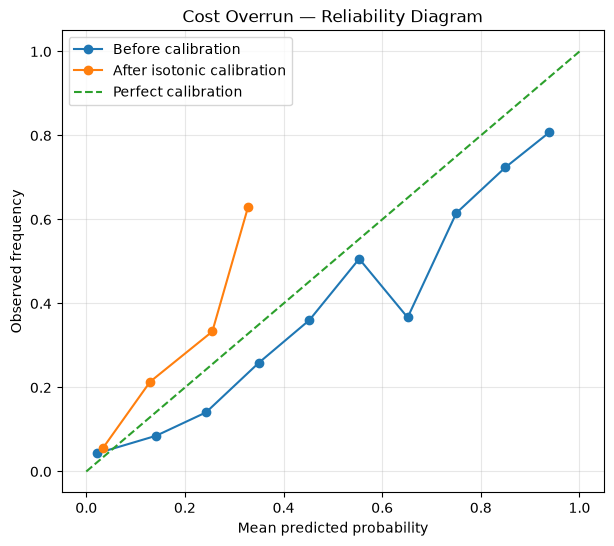

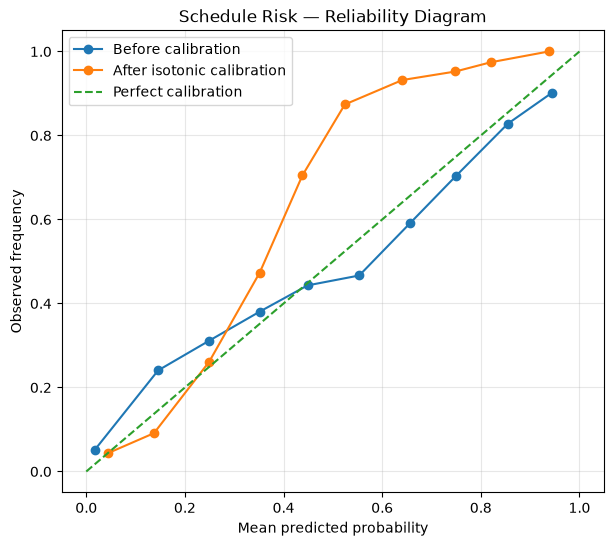

In [75]:
# ==========================================
# PHASE 3 — RELIABILITY DIAGRAMS
# ==========================================

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# ==========================================
# COST RELIABILITY
# ==========================================

cost_true_before, cost_pred_before = calibration_curve(
    y_test,
    cost_prob_before,
    n_bins=10,
    strategy="uniform"
)

cost_true_after, cost_pred_after = calibration_curve(
    y_test,
    cost_prob_after,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 6))

plt.plot(
    cost_pred_before,
    cost_true_before,
    marker="o",
    label="Before calibration"
)

plt.plot(
    cost_pred_after,
    cost_true_after,
    marker="o",
    label="After isotonic calibration"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency")
plt.title("Cost Overrun — Reliability Diagram")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ==========================================
# SCHEDULE RELIABILITY
# ==========================================

schedule_true_before, schedule_pred_before = calibration_curve(
    y_schedule_test,
    schedule_prob_before,
    n_bins=10,
    strategy="uniform"
)

schedule_true_after, schedule_pred_after = calibration_curve(
    y_schedule_test,
    schedule_prob_after,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 6))

plt.plot(
    schedule_pred_before,
    schedule_true_before,
    marker="o",
    label="Before calibration"
)

plt.plot(
    schedule_pred_after,
    schedule_true_after,
    marker="o",
    label="After isotonic calibration"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency")
plt.title("Schedule Risk — Reliability Diagram")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [76]:
# ==========================================
# PHASE 3 — FINAL CALIBRATION DIAGNOSTICS
# ==========================================

import numpy as np

def calibration_summary(y_true, prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)

    rows = []

    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (prob >= bins[i]) & (prob <= bins[i + 1])
        else:
            mask = (prob >= bins[i]) & (prob < bins[i + 1])

        if mask.sum() == 0:
            continue

        predicted = prob[mask].mean()
        observed = y_true[mask].mean()

        rows.append({
            "Bin": f"{bins[i]:.1f}-{bins[i+1]:.1f}",
            "Count": mask.sum(),
            "Mean Predicted": predicted,
            "Observed Rate": observed,
            "Absolute Error": abs(predicted - observed)
        })

    result = pd.DataFrame(rows)

    ece = (
        result["Absolute Error"] *
        result["Count"] /
        result["Count"].sum()
    ).sum()

    return result, ece


cost_calibration_table, cost_ece = calibration_summary(
    y_test,
    cost_prob_before
)

schedule_calibration_table, schedule_ece = calibration_summary(
    y_schedule_test,
    schedule_prob_before
)

final_calibration_summary = pd.DataFrame({
    "Target": [
        "Cost Overrun",
        "Schedule Risk"
    ],
    "Brier Score": [
        cost_brier_before,
        schedule_brier_before
    ],
    "ECE": [
        cost_ece,
        schedule_ece
    ]
})

print("FINAL UNCALIBRATED PROBABILITY DIAGNOSTICS")
display(final_calibration_summary.round(4))

FINAL UNCALIBRATED PROBABILITY DIAGNOSTICS


,Target,Brier Score,ECE
0,Cost Overrun,0.0622,0.0352
1,Schedule Risk,0.1259,0.0438


In [78]:
# ==========================================
# CALIBRATION TABLES
# ==========================================

print("COST OVERRUN CALIBRATION")
display(cost_calibration_table.round(4))

print("\nSCHEDULE RISK CALIBRATION")
display(schedule_calibration_table.round(4))

COST OVERRUN CALIBRATION


,Bin,Count,Mean Predicted,Observed Rate,Absolute Error
0,0.0-0.1,6108,0.0209,0.0429,0.0220
1,0.1-0.2,482,0.1416,0.0851,0.0565
2,0.2-0.3,206,0.2429,0.1408,0.1021
3,0.3-0.4,112,0.3499,0.2589,0.0910
4,0.4-0.5,86,0.4524,0.3605,0.0919
5,0.5-0.6,79,0.5534,0.5063,0.0471
6,0.6-0.7,90,0.6516,0.3667,0.2850
7,0.7-0.8,91,0.7503,0.6154,0.1350
8,0.8-0.9,87,0.8499,0.7241,0.1257
9,0.9-1.0,52,0.9391,0.8077,0.1314



SCHEDULE RISK CALIBRATION


,Bin,Count,Mean Predicted,Observed Rate,Absolute Error
0,0.0-0.1,2169,0.0173,0.0516,0.0343
1,0.1-0.2,403,0.1457,0.2407,0.0950
2,0.2-0.3,247,0.2497,0.3117,0.0621
3,0.3-0.4,218,0.3518,0.3807,0.0289
4,0.4-0.5,246,0.4487,0.4431,0.0056
5,0.5-0.6,210,0.5534,0.4667,0.0868
6,0.6-0.7,247,0.6564,0.5911,0.0653
7,0.7-0.8,280,0.7495,0.7036,0.0459
8,0.8-0.9,378,0.8547,0.8280,0.0267
9,0.9-1.0,427,0.9442,0.9016,0.0425


In [80]:
# ==========================================
# PHASE 4 — SHAP EXPLAINABILITY
# ==========================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cost_final_model = search.best_estimator_
schedule_final_model = schedule_search.best_estimator_

print("Cost model:", type(cost_final_model))
print("Schedule model:", type(schedule_final_model))

print("\nSHAP version:", shap.__version__)

C:\Users\vatsh\OneDrive\Desktop\ml\meowwww\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cost model: <class 'sklearn.pipeline.Pipeline'>
Schedule model: <class 'sklearn.pipeline.Pipeline'>

SHAP version: 0.52.0


In [81]:
# ==========================================
# TRANSFORM DATA FOR SHAP
# ==========================================

# -------------------------------
# COST
# -------------------------------

cost_preprocessor = cost_final_model.named_steps["preprocessor"]
cost_xgb = cost_final_model.named_steps["model"]

X_cost_shap = cost_preprocessor.transform(X_test)

cost_feature_names = (
    cost_preprocessor.get_feature_names_out()
)

print("Cost transformed shape:", X_cost_shap.shape)
print("Cost SHAP features:", len(cost_feature_names))


# -------------------------------
# SCHEDULE
# -------------------------------

schedule_preprocessor = schedule_final_model.named_steps["preprocessor"]
schedule_xgb = schedule_final_model.named_steps["model"]

X_schedule_shap = schedule_preprocessor.transform(
    X_schedule_test
)

schedule_feature_names = (
    schedule_preprocessor.get_feature_names_out()
)

print(
    "\nSchedule transformed shape:",
    X_schedule_shap.shape
)

print(
    "Schedule SHAP features:",
    len(schedule_feature_names)
)

Cost transformed shape: (7393, 106)
Cost SHAP features: 106

Schedule transformed shape: (4825, 105)
Schedule SHAP features: 105


In [82]:
# ==========================================
# CALCULATE SHAP VALUES
# ==========================================

# Limit SHAP computation for speed
SHAP_SAMPLE_SIZE = min(3000, X_cost_shap.shape[0])

rng = np.random.RandomState(42)

cost_indices = rng.choice(
    X_cost_shap.shape[0],
    size=SHAP_SAMPLE_SIZE,
    replace=False
)

schedule_indices = rng.choice(
    X_schedule_shap.shape[0],
    size=min(
        SHAP_SAMPLE_SIZE,
        X_schedule_shap.shape[0]
    ),
    replace=False
)

# -------------------------------
# COST SHAP
# -------------------------------

cost_explainer = shap.TreeExplainer(cost_xgb)

cost_shap_values = cost_explainer.shap_values(
    X_cost_shap[cost_indices]
)

print("Cost SHAP calculated:",
      cost_shap_values.shape)


# -------------------------------
# SCHEDULE SHAP
# -------------------------------

schedule_explainer = shap.TreeExplainer(
    schedule_xgb
)

schedule_shap_values = schedule_explainer.shap_values(
    X_schedule_shap[schedule_indices]
)

print(
    "Schedule SHAP calculated:",
    schedule_shap_values.shape
)

Cost SHAP calculated: (3000, 106)
Schedule SHAP calculated: (3000, 105)


In [83]:
# ==========================================
# GLOBAL SHAP FEATURE IMPORTANCE
# ==========================================

# -------------------------------
# COST
# -------------------------------

cost_importance = pd.DataFrame({
    "Feature": cost_feature_names,
    "Mean |SHAP|": np.abs(cost_shap_values).mean(axis=0)
})

cost_importance = cost_importance.sort_values(
    "Mean |SHAP|",
    ascending=False
).reset_index(drop=True)

print("TOP COST OVERRUN FEATURES")
display(cost_importance.head(20))


# -------------------------------
# SCHEDULE
# -------------------------------

schedule_importance = pd.DataFrame({
    "Feature": schedule_feature_names,
    "Mean |SHAP|": np.abs(schedule_shap_values).mean(axis=0)
})

schedule_importance = schedule_importance.sort_values(
    "Mean |SHAP|",
    ascending=False
).reset_index(drop=True)

print("\nTOP SCHEDULE RISK FEATURES")
display(schedule_importance.head(20))

TOP COST OVERRUN FEATURES


,Feature,Mean |SHAP|
0,cat__sector_ROAD TRANSPORT AND HIGHWAYS,0.714610
1,num__project_age,0.403686
2,num__anticipated_cost_percentage,0.376797
3,num__exp_vs_anti_prct,0.324236
4,num__sector_overrun_rate,0.318324
5,num__anticipated_cost_crore,0.313190
6,num__original_duration_months,0.266588
7,num__approval_year,0.233913
8,num__year,0.225597
9,num__current_cost,0.204834



TOP SCHEDULE RISK FEATURES


,Feature,Mean |SHAP|
0,num__anticipated_delay_from_original,1.008227
1,num__remaining_org_months,0.666478
2,num__sector_overrun_rate,0.567790
3,num__project_duration_elapsed_percentage,0.244056
4,num__duration_overrun_months,0.239961
5,num__original_duration_months,0.214053
6,num__schedule_change_12m,0.154035
7,num__project_age,0.142988
8,num__expenditure_growth_12m,0.133283
9,num__anticipated_cost_crore,0.131905


In [84]:
# ==========================================
# PHASE 4.2 — CLEAN SHAP FEATURE MAPPING
# ==========================================

def clean_shap_feature_name(name):
    """
    Convert transformed preprocessing names
    into readable original feature names.
    """

    if name.startswith("num_"):
        return name.replace("num_", "", 1)

    if name.startswith("cat_"):
        # Example:
        # cat_sector_ROAD TRANSPORT AND HIGHWAYS
        # -> sector
        return name.split("_", 2)[1]

    return name


cost_shap_features = pd.DataFrame({
    "transformed_feature": cost_feature_names,
    "feature": [
        clean_shap_feature_name(x)
        for x in cost_feature_names
    ],
    "mean_abs_shap": np.abs(cost_shap_values).mean(axis=0)
})

schedule_shap_features = pd.DataFrame({
    "transformed_feature": schedule_feature_names,
    "feature": [
        clean_shap_feature_name(x)
        for x in schedule_feature_names
    ],
    "mean_abs_shap": np.abs(schedule_shap_values).mean(axis=0)
})

print("COST SHAP MAPPING")
display(cost_shap_features.head(15))

print("\nSCHEDULE SHAP MAPPING")
display(schedule_shap_features.head(15))

COST SHAP MAPPING


,transformed_feature,feature,mean_abs_shap
0,num__month,_month,0.126964
1,num__year,_year,0.225597
2,num__approval_year,_approval_year,0.233913
3,num__project_age,_project_age,0.403686
4,num__original_duration_months,_original_duration_months,0.266588
5,num__duration_overrun_months,_duration_overrun_months,0.090645
6,num__original_cost_crore,_original_cost_crore,0.173203
7,num__revised_cost_crore,_revised_cost_crore,0.051179
8,num__anticipated_cost_crore,_anticipated_cost_crore,0.313190
9,num__current_cost,_current_cost,0.204834



SCHEDULE SHAP MAPPING


,transformed_feature,feature,mean_abs_shap
0,num__month,_month,0.036998
1,num__year,_year,0.083244
2,num__approval_year,_approval_year,0.098789
3,num__project_age,_project_age,0.142988
4,num__original_duration_months,_original_duration_months,0.214053
5,num__duration_overrun_months,_duration_overrun_months,0.239961
6,num__original_cost_crore,_original_cost_crore,0.106064
7,num__revised_cost_crore,_revised_cost_crore,0.035211
8,num__anticipated_cost_crore,_anticipated_cost_crore,0.131905
9,num__current_cost,_current_cost,0.079083


In [85]:
# ==========================================
# LOCAL EXPLANATION FUNCTION
# ==========================================

def explain_prediction(project_id, report_month, target="cost"):

    report_month = pd.Timestamp(report_month)

    # --------------------------------------
    # Select correct model/data
    # --------------------------------------

    if target == "cost":
        model = cost_final_model
        preprocessor = cost_preprocessor
        xgb = cost_xgb

        source_df = df[
            (df["project_id"] == project_id) &
            (df["report_month"] == report_month)
        ]

    elif target == "schedule":
        model = schedule_final_model
        preprocessor = schedule_preprocessor
        xgb = schedule_xgb

        source_df = df[
            (df["project_id"] == project_id) &
            (df["report_month"] == report_month)
        ]

    else:
        raise ValueError(
            "target must be 'cost' or 'schedule'"
        )

    if len(source_df) == 0:
        return {
            "error": "Project/date combination not found."
        }

    # --------------------------------------
    # Get model features
    # --------------------------------------

    drop_cols_local = [
        "project_id",
        "project_name",
        "report_month",
        "target_cost_overrun_12m",
        "target_schedule_risk_12m",
        "cost_target_valid",
        "serial_no",
        "source_file",
        "source_page",
        "implementing_agency"
    ]

    drop_cols_local = [
        c for c in drop_cols_local
        if c in source_df.columns
    ]

    X_local = source_df.drop(
        columns=drop_cols_local
    )

    # --------------------------------------
    # Transform
    # --------------------------------------

    X_transformed = preprocessor.transform(X_local)

    # --------------------------------------
    # Prediction
    # --------------------------------------

    probability = model.predict_proba(X_local)[0, 1]

    # --------------------------------------
    # SHAP
    # --------------------------------------

    explainer = shap.TreeExplainer(xgb)

    shap_values = explainer.shap_values(
        X_transformed
    )[0]

    # --------------------------------------
    # Build driver table
    # --------------------------------------

    feature_names = (
        preprocessor.get_feature_names_out()
    )

    driver_df = pd.DataFrame({
        "transformed_feature": feature_names,
        "shap_value": shap_values,
        "abs_shap": np.abs(shap_values)
    })

    driver_df["feature"] = [
        clean_shap_feature_name(x)
        for x in feature_names
    ]

    # strongest drivers
    driver_df = driver_df.sort_values(
        "abs_shap",
        ascending=False
    )

    return {
        "project_id": project_id,
        "report_month": str(report_month.date()),
        "target": target,
        "probability": probability,
        "drivers": driver_df.head(10)
    }

print("explain_prediction() created.")

explain_prediction() created.


In [86]:
# ==========================================
# TEST LOCAL EXPLANATION
# ==========================================

example_index = X_test.index[0]

example_project = df.loc[
    example_index,
    "project_id"
]

example_date = df.loc[
    example_index,
    "report_month"
]

print("Testing:")
print("Project ID:", example_project)
print("Report Month:", example_date)

cost_explanation = explain_prediction(
    example_project,
    example_date,
    target="cost"
)

schedule_explanation = explain_prediction(
    example_project,
    example_date,
    target="schedule"
)

print("\nCOST RISK:")
print(
    "Probability:",
    round(cost_explanation["probability"], 4)
)

display(
    cost_explanation["drivers"][
        [
            "feature",
            "transformed_feature",
            "shap_value",
            "abs_shap"
        ]
    ].head(5)
)

print("\nSCHEDULE RISK:")
print(
    "Probability:",
    round(schedule_explanation["probability"], 4)
)

display(
    schedule_explanation["drivers"][
        [
            "feature",
            "transformed_feature",
            "shap_value",
            "abs_shap"
        ]
    ].head(5)
)

Testing:
Project ID: 180100078
Report Month: 2021-01-01 00:00:00

COST RISK:
Probability: 0.8508


,feature,transformed_feature,shap_value,abs_shap
3,_project_age,num__project_age,0.559346,0.559346
5,_duration_overrun_months,num__duration_overrun_months,0.458833,0.458833
2,_approval_year,num__approval_year,0.455076,0.455076
59,,cat__sector_POWER,0.424227,0.424227
20,_exp_vs_anti_prct,num__exp_vs_anti_prct,-0.370676,0.370676



SCHEDULE RISK:
Probability: 0.0002


,feature,transformed_feature,shap_value,abs_shap
11,_anticipated_delay_from_original,num__anticipated_delay_from_original,-2.554935,2.554935
12,_remaining_org_months,num__remaining_org_months,-2.383406,2.383406
5,_duration_overrun_months,num__duration_overrun_months,-0.841432,0.841432
3,_project_age,num__project_age,-0.538545,0.538545
10,_cumulative_expenditure_crore,num__cumulative_expenditure_crore,-0.479101,0.479101


In [87]:
# ==========================================
# PLAIN-LANGUAGE SHAP DRIVERS
# ==========================================

FEATURE_LABELS = {
    "project_age": "project age",
    "anticipated_cost_percentage": "anticipated cost percentage",
    "exp_vs_anti_prct": "expenditure vs anticipated cost",
    "sector_overrun_rate": "historical sector overrun rate",
    "anticipated_cost_crore": "anticipated project cost",
    "original_duration_months": "original project duration",
    "approval_year": "approval year",
    "current_cost": "current project cost",
    "cumulative_expenditure_crore": "cumulative expenditure",
    "project_duration_elapsed_percentage":
        "project duration elapsed",
    "anticipated_delay_from_original":
        "anticipated delay from original schedule",
    "remaining_org_months":
        "remaining original schedule",
    "duration_overrun_months":
        "duration overrun",
    "schedule_change_12m":
        "12-month schedule change",
    "expenditure_growth_12m":
        "12-month expenditure growth",
    "agency_overrun_rate":
        "historical agency overrun rate",
    "milestone_completion_percentage":
        "milestone completion percentage"
}


def get_plain_drivers(explanation, top_n=5):

    drivers = explanation["drivers"].head(top_n)

    output = []

    for _, row in drivers.iterrows():

        feature = row["feature"]

        label = FEATURE_LABELS.get(
            feature,
            feature.replace("_", " ")
        )

        direction = (
            "increases risk"
            if row["shap_value"] > 0
            else "reduces risk"
        )

        output.append({
            "driver": label,
            "direction": direction,
            "shap_value": round(
                float(row["shap_value"]), 4
            )
        })

    return output


print("COST DRIVERS")
for driver in get_plain_drivers(
    cost_explanation
):
    print(
        f"- {driver['driver']}: "
        f"{driver['direction']}"
    )

print("\nSCHEDULE DRIVERS")
for driver in get_plain_drivers(
    schedule_explanation
):
    print(
        f"- {driver['driver']}: "
        f"{driver['direction']}"
    )

COST DRIVERS
-  project age: increases risk
-  duration overrun months: increases risk
-  approval year: increases risk
- : increases risk
-  exp vs anti prct: reduces risk

SCHEDULE DRIVERS
-  anticipated delay from original: reduces risk
-  remaining org months: reduces risk
-  duration overrun months: reduces risk
-  project age: reduces risk
-  cumulative expenditure crore: reduces risk


In [88]:
# ==========================================
# FIX SHAP FEATURE NAME MAPPING
# ==========================================

def clean_shap_feature_name(name):

    # Numeric features:
    # num__project_age -> project_age
    if name.startswith("num__"):
        return name.replace("num__", "", 1)

    # One-hot categorical features:
    # cat__sector_POWER -> sector
    if name.startswith("cat__"):
        remainder = name.replace("cat__", "", 1)

        # sector_POWER -> sector
        # state_DELHI -> state
        return remainder.split("_", 1)[0]

    return name


# Rebuild mappings
cost_shap_features["feature"] = [
    clean_shap_feature_name(x)
    for x in cost_shap_features["transformed_feature"]
]

schedule_shap_features["feature"] = [
    clean_shap_feature_name(x)
    for x in schedule_shap_features["transformed_feature"]
]

print("COST TOP FEATURES")
display(
    cost_shap_features
    .sort_values("mean_abs_shap", ascending=False)
    .head(15)
)

print("\nSCHEDULE TOP FEATURES")
display(
    schedule_shap_features
    .sort_values("mean_abs_shap", ascending=False)
    .head(15)
)

COST TOP FEATURES


,transformed_feature,feature,mean_abs_shap
61,cat__sector_ROAD TRANSPORT AND HIGHWAYS,sector,0.714610
3,num__project_age,project_age,0.403686
19,num__anticipated_cost_percentage,anticipated_cost_percentage,0.376797
20,num__exp_vs_anti_prct,exp_vs_anti_prct,0.324236
42,num__sector_overrun_rate,sector_overrun_rate,0.318324
8,num__anticipated_cost_crore,anticipated_cost_crore,0.313190
4,num__original_duration_months,original_duration_months,0.266588
2,num__approval_year,approval_year,0.233913
1,num__year,year,0.225597
9,num__current_cost,current_cost,0.204834



SCHEDULE TOP FEATURES


,transformed_feature,feature,mean_abs_shap
11,num__anticipated_delay_from_original,anticipated_delay_from_original,1.008227
12,num__remaining_org_months,remaining_org_months,0.666478
42,num__sector_overrun_rate,sector_overrun_rate,0.567790
23,num__project_duration_elapsed_percentage,project_duration_elapsed_percentage,0.244056
5,num__duration_overrun_months,duration_overrun_months,0.239961
4,num__original_duration_months,original_duration_months,0.214053
32,num__schedule_change_12m,schedule_change_12m,0.154035
3,num__project_age,project_age,0.142988
29,num__expenditure_growth_12m,expenditure_growth_12m,0.133283
8,num__anticipated_cost_crore,anticipated_cost_crore,0.131905


In [89]:
# ==========================================
# LOCAL SHAP EXPLANATION — CLEAN VERSION
# ==========================================

def explain_prediction(project_id, report_month, target="cost"):

    report_month = pd.Timestamp(report_month)

    if target == "cost":
        model = cost_final_model
        preprocessor = cost_preprocessor
        xgb = cost_xgb

    elif target == "schedule":
        model = schedule_final_model
        preprocessor = schedule_preprocessor
        xgb = schedule_xgb

    else:
        raise ValueError("target must be 'cost' or 'schedule'")

    # Find project/date
    source_df = df[
        (df["project_id"] == project_id) &
        (df["report_month"] == report_month)
    ].copy()

    if len(source_df) == 0:
        return {"error": "Project/date combination not found."}

    # Same exclusions as final models
    drop_cols_local = [
        "project_id",
        "project_name",
        "report_month",
        "target_cost_overrun_12m",
        "target_schedule_risk_12m",
        "cost_target_valid",
        "serial_no",
        "source_file",
        "source_page",
        "implementing_agency"
    ]

    drop_cols_local = [
        c for c in drop_cols_local
        if c in source_df.columns
    ]

    X_local = source_df.drop(columns=drop_cols_local)

    # Transform
    X_transformed = preprocessor.transform(X_local)

    # Probability
    probability = model.predict_proba(X_local)[0, 1]

    # SHAP
    explainer = shap.TreeExplainer(xgb)
    shap_values = explainer.shap_values(X_transformed)[0]

    feature_names = preprocessor.get_feature_names_out()

    # Actual transformed values
    if hasattr(X_transformed, "toarray"):
        values = X_transformed.toarray()[0]
    else:
        values = X_transformed[0]

    drivers = pd.DataFrame({
        "transformed_feature": feature_names,
        "value": values,
        "shap_value": shap_values,
        "abs_shap": np.abs(shap_values)
    })

    drivers["feature"] = [
        clean_shap_feature_name(x)
        for x in feature_names
    ]

    drivers = drivers.sort_values(
        "abs_shap",
        ascending=False
    ).reset_index(drop=True)

    return {
        "project_id": project_id,
        "report_month": str(report_month.date()),
        "target": target,
        "probability": float(probability),
        "drivers": drivers
    }

print("Clean explain_prediction() created.")

Clean explain_prediction() created.


In [90]:
# ==========================================
# TEST CORRECTED LOCAL EXPLANATIONS
# ==========================================

cost_explanation = explain_prediction(
    example_project,
    example_date,
    target="cost"
)

schedule_explanation = explain_prediction(
    example_project,
    example_date,
    target="schedule"
)

print("COST")
print(
    "Risk score:",
    round(cost_explanation["probability"], 4)
)

display(
    cost_explanation["drivers"][
        [
            "feature",
            "value",
            "shap_value",
            "abs_shap"
        ]
    ].head(5)
)


print("\nSCHEDULE")
print(
    "Risk score:",
    round(schedule_explanation["probability"], 4)
)

display(
    schedule_explanation["drivers"][
        [
            "feature",
            "value",
            "shap_value",
            "abs_shap"
        ]
    ].head(5)
)

COST
Risk score: 0.8508


,feature,value,shap_value,abs_shap
0,project_age,2.824131,0.559346,0.559346
1,duration_overrun_months,5.421818,0.458833,0.458833
2,approval_year,-2.345417,0.455076,0.455076
3,sector,1.000000,0.424227,0.424227
4,exp_vs_anti_prct,-0.775501,-0.370676,0.370676



SCHEDULE
Risk score: 0.0002


,feature,value,shap_value,abs_shap
0,anticipated_delay_from_original,-0.388962,-2.554935,2.554935
1,remaining_org_months,-3.918687,-2.383406,2.383406
2,duration_overrun_months,4.867405,-0.841432,0.841432
3,project_age,2.918496,-0.538545,0.538545
4,cumulative_expenditure_crore,-0.336658,-0.479101,0.479101


In [91]:
# ==========================================
# CLEAN TOP-DRIVER OUTPUT
# ==========================================

def get_top_drivers(explanation, top_n=5):

    drivers = explanation["drivers"].head(top_n)

    output = []

    for _, row in drivers.iterrows():

        feature = row["feature"]

        label = FEATURE_LABELS.get(
            feature,
            feature.replace("_", " ")
        )

        direction = (
            "increases risk"
            if row["shap_value"] > 0
            else "reduces risk"
        )

        output.append({
            "feature": label,
            "direction": direction,
            "shap_value": round(
                float(row["shap_value"]), 4
            )
        })

    return output


print("COST TOP DRIVERS")
for x in get_top_drivers(cost_explanation):
    print(
        f"• {x['feature']} → {x['direction']}"
    )

print("\nSCHEDULE TOP DRIVERS")
for x in get_top_drivers(schedule_explanation):
    print(
        f"• {x['feature']} → {x['direction']}"
    )

COST TOP DRIVERS
• project age → increases risk
• duration overrun → increases risk
• approval year → increases risk
• sector → increases risk
• expenditure vs anticipated cost → reduces risk

SCHEDULE TOP DRIVERS
• anticipated delay from original schedule → reduces risk
• remaining original schedule → reduces risk
• duration overrun → reduces risk
• project age → reduces risk
• cumulative expenditure → reduces risk


In [92]:
import joblib

phase4_checkpoint = {
    # Final tuned models
    "cost_final_model": cost_final_model,
    "schedule_final_model": schedule_final_model,

    # SHAP results
    "cost_shap_features": cost_shap_features,
    "schedule_shap_features": schedule_shap_features,

    "cost_shap_values": cost_shap_values,
    "schedule_shap_values": schedule_shap_values,

    "cost_feature_names": cost_feature_names,
    "schedule_feature_names": schedule_feature_names,

    # Example used for testing
    "example_project": example_project,
    "example_date": example_date
}

joblib.dump(
    phase4_checkpoint,
    "phase4_checkpoint.joblib"
)

print("✅ Phase 4 checkpoint saved.")

✅ Phase 4 checkpoint saved.
